In [1]:
DATA_DIR = "../data/raw"
TRAIN_DIR = "../data/raw/train"
LABELS_PATH = "../data/raw/labels.csv"

In [2]:
import pandas as pd

df = pd.read_csv(LABELS_PATH)
print(df.head())

                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


In [4]:
# How many unique dog breeds are there?
df['breed'].nunique()

120

In [5]:
# What are the most common dog breeds in the dataset?
df['breed'].value_counts().head()

breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
Name: count, dtype: int64

Image ID: 000bec180eb18c7604dcecc8fe0dba07, Label: boston_bull


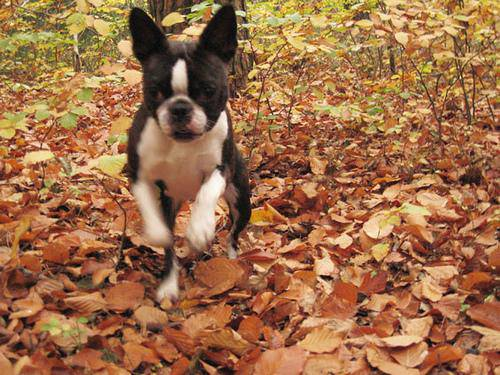

In [7]:
# Let's visualize one of the images in the dataset.
import os
from PIL import Image

row = df.iloc[0]
img_id = row['id']
label = row['breed']
print(f"Image ID: {img_id}, Label: {label}")

img_path = os.path.join(TRAIN_DIR, img_id + ".jpg")

img = Image.open(img_path)
img

In [10]:
img_path = os.path.join(TRAIN_DIR, df.iloc[0]['id'] + ".jpg")
print(os.path.exists(img_path))

True


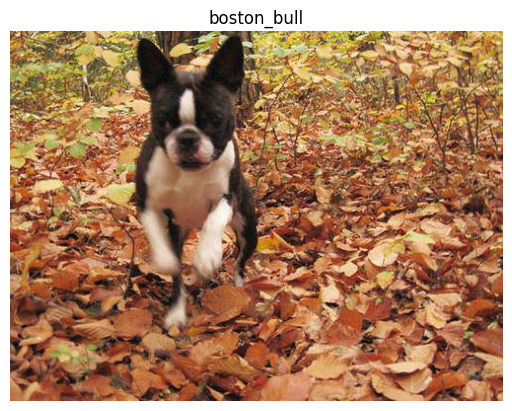

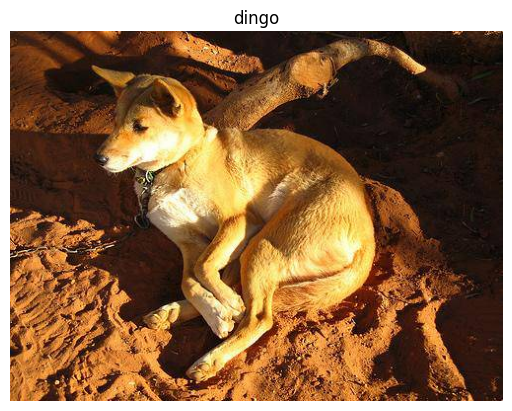

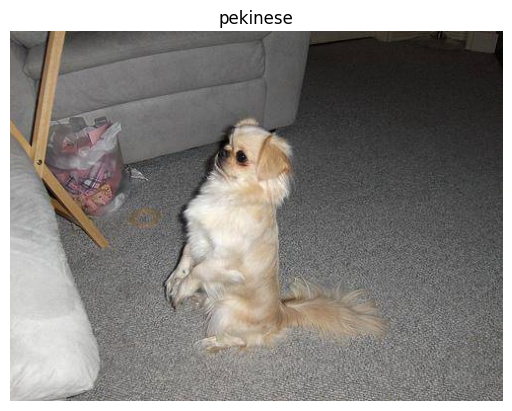

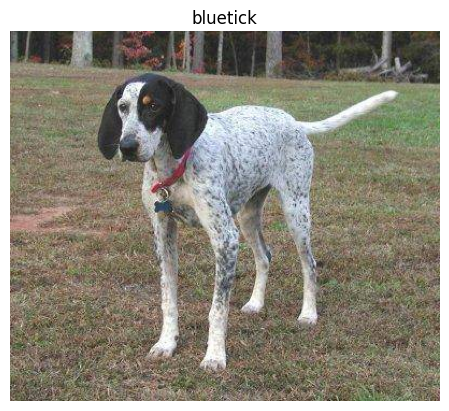

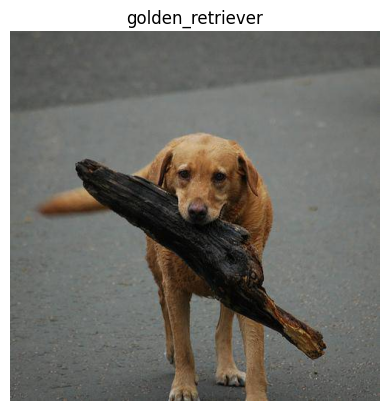

In [11]:
for i in range(5):
    row = df.iloc[i]
    img_id = row['id']
    label = row['breed']
    
    img_path = os.path.join(TRAIN_DIR, img_id + ".jpg")
    img = Image.open(img_path)
    
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
    plt.show()

## Dataset Overview

- Dataset: Kaggle Dog Breed Identification
- Number of samples: ~10,000+ (train)
- Number of classes: 120 dog breeds

### Structure
- labels.csv:
  - id → image filename
  - breed → class label

- train/:
  - contains images named as: id.jpg

### Example
- id: 000bec180eb18c7604dcecc8fe0dba07
- label: boston_bull
- image path: train/000bec180eb18c7604dcecc8fe0dba07.jpg

### Observations
- Classes seem relatively balanced (~100+ images per class)
- Labels are strings → will need encoding to integers later

In [27]:
# Create mapping from breed name to integer label
# breed_to_idx = {breed: idx for idx, breed in enumerate(df['breed'].unique())}
breed_to_idx = {breed: idx for idx, breed in enumerate(sorted(df['breed'].unique()))} # better version for reproducibility
print(breed_to_idx)

{'affenpinscher': 0, 'afghan_hound': 1, 'african_hunting_dog': 2, 'airedale': 3, 'american_staffordshire_terrier': 4, 'appenzeller': 5, 'australian_terrier': 6, 'basenji': 7, 'basset': 8, 'beagle': 9, 'bedlington_terrier': 10, 'bernese_mountain_dog': 11, 'black-and-tan_coonhound': 12, 'blenheim_spaniel': 13, 'bloodhound': 14, 'bluetick': 15, 'border_collie': 16, 'border_terrier': 17, 'borzoi': 18, 'boston_bull': 19, 'bouvier_des_flandres': 20, 'boxer': 21, 'brabancon_griffon': 22, 'briard': 23, 'brittany_spaniel': 24, 'bull_mastiff': 25, 'cairn': 26, 'cardigan': 27, 'chesapeake_bay_retriever': 28, 'chihuahua': 29, 'chow': 30, 'clumber': 31, 'cocker_spaniel': 32, 'collie': 33, 'curly-coated_retriever': 34, 'dandie_dinmont': 35, 'dhole': 36, 'dingo': 37, 'doberman': 38, 'english_foxhound': 39, 'english_setter': 40, 'english_springer': 41, 'entlebucher': 42, 'eskimo_dog': 43, 'flat-coated_retriever': 44, 'french_bulldog': 45, 'german_shepherd': 46, 'german_short-haired_pointer': 47, 'gian

In [28]:
# Mapping from integer label to breed name
idx_to_breed = {idx: breed for breed, idx in breed_to_idx.items()}
print(idx_to_breed)

{0: 'affenpinscher', 1: 'afghan_hound', 2: 'african_hunting_dog', 3: 'airedale', 4: 'american_staffordshire_terrier', 5: 'appenzeller', 6: 'australian_terrier', 7: 'basenji', 8: 'basset', 9: 'beagle', 10: 'bedlington_terrier', 11: 'bernese_mountain_dog', 12: 'black-and-tan_coonhound', 13: 'blenheim_spaniel', 14: 'bloodhound', 15: 'bluetick', 16: 'border_collie', 17: 'border_terrier', 18: 'borzoi', 19: 'boston_bull', 20: 'bouvier_des_flandres', 21: 'boxer', 22: 'brabancon_griffon', 23: 'briard', 24: 'brittany_spaniel', 25: 'bull_mastiff', 26: 'cairn', 27: 'cardigan', 28: 'chesapeake_bay_retriever', 29: 'chihuahua', 30: 'chow', 31: 'clumber', 32: 'cocker_spaniel', 33: 'collie', 34: 'curly-coated_retriever', 35: 'dandie_dinmont', 36: 'dhole', 37: 'dingo', 38: 'doberman', 39: 'english_foxhound', 40: 'english_setter', 41: 'english_springer', 42: 'entlebucher', 43: 'eskimo_dog', 44: 'flat-coated_retriever', 45: 'french_bulldog', 46: 'german_shepherd', 47: 'german_short-haired_pointer', 48: '

In [29]:
# PyTorch Dataset class
from torch.utils.data import Dataset

class DogDataset(Dataset):
    def __init__(self, df, img_dir, breed_to_idx, transform=None):
        self.df = df.reset_index(drop=True) # reset index to avoid weird index issues after splitting
        self.img_dir = img_dir
        self.transform = transform
        self.breed_to_idx = breed_to_idx # cleaner than creating this mapping inside __getitem__ every time

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['id']
        breed = row['breed']
        
        img_path = os.path.join(self.img_dir, img_id + ".jpg")
        image = Image.open(img_path).convert("RGB") # model expects 3 channels
        
        label = self.breed_to_idx[breed] # convert breed name to integer label using the mapping we created
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [30]:
dataset = DogDataset(df, TRAIN_DIR, breed_to_idx)

print(len(dataset))

img, label = dataset[0]
print(type(img), label, idx_to_breed[label])

img, label = dataset[10]
print(type(img), label, idx_to_breed[label])

img, label = dataset[100]
print(type(img), label, idx_to_breed[label])

10222
<class 'PIL.Image.Image'> 19 boston_bull
<class 'PIL.Image.Image'> 99 shetland_sheepdog
<class 'PIL.Image.Image'> 90 rhodesian_ridgeback


In [ ]:
from torchvision import transforms

# Train traoforms with data augmentation, resize, and normalization
train_transform = transforms.Compose([
    # transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224), # better than just resizing for data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test transforms with just resize and normalization
test_transform = transforms.Compose([
    # transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

- Why resize: models expect fixed input size (ResNet trained on 224×224)
- Why normalize: pretrained models expect ImageNet distribution
- Why augmentation only for train: to improve generalization, not to corrupt evaluation

In [34]:
dataset = DogDataset(df, TRAIN_DIR, breed_to_idx, transform=train_transform)

img, label = dataset[0]
print(type(img))
print(img.shape)
print(img.min(), img.max())

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
tensor(-2.1179) tensor(2.4483)


In [37]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# Split the dataframe into train and validation sets with 80/20 split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, 
                                    stratify=df['breed']) # stratify to maintain class distribution in train and val sets

# Create train and validation datasets
train_dataset = DogDataset(train_df, TRAIN_DIR, breed_to_idx, transform=train_transform)
val_dataset = DogDataset(val_df, TRAIN_DIR, breed_to_idx, transform=test_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # shuffle=True for training to help with generalization
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) # no need to shuffle validation data

In [38]:
# Inspect one batch
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([  9,  76,  52,   5,  97,  92, 114,  51,  99,  70])


In [78]:
from torchvision import models
import torch.nn as nn

# Load pre-trained ResNet-18 model
model = models.resnet18(pretrained=True)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

/opt/miniconda3/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [79]:
# Adjust the final fully connected layer to match the number of dog breeds (120)
num_breeds = len(breed_to_idx)
model.fc = nn.Linear(model.fc.in_features, num_breeds)
print(model.fc)

Linear(in_features=512, out_features=120, bias=True)


In [80]:
# Freeze all layers except the final fully connected layer
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

In [81]:
print(model.conv1.weight.requires_grad)  # should be False
print(model.fc.weight.requires_grad)     # should be True

False
True


In [82]:
# Set device to GPU if available
import torch
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)

In [83]:
# Test foward pass
outputs = model(images)
print(outputs.shape)

torch.Size([29, 120])


In [84]:
# Learning rate and optimizer
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.fc.parameters(), # only optimize the final layer since we're freezing the rest of the model
    lr=1e-3)

In [85]:
# One training step
model.train() # set model to training mode
images, labels = next(iter(train_loader)) # get one batch of data
images, labels = images.to(device), labels.to(device) # move data to the same device
optimizer.zero_grad() # zero the gradients
outputs = model(images) # forward pass
loss = criterion(outputs, labels) # compute loss
print(f"Loss: {loss.item()}")
loss.backward() # backward pass
optimizer.step() # update weights

Loss: 5.204131126403809


In [ ]:
# Multiple epochs of training and validation
num_epochs = 5
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # One epoch of training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0) # accumulate loss weighted by batch size
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # One epoch of validation
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_running_loss / val_total
    val_epoch_acc = val_correct / val_total

    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}")
    print(f"Val   Loss: {val_epoch_loss:.4f}, Val   Acc: {val_epoch_acc:.4f}")
    print("-" * 40)

Epoch 1/5
Train Loss: 2.9209, Train Acc: 0.3725
Val   Loss: 1.7008, Val   Acc: 0.5941
----------------------------------------
Epoch 2/5
Train Loss: 1.4604, Train Acc: 0.6491
Val   Loss: 1.2856, Val   Acc: 0.6582
----------------------------------------
Epoch 3/5
Train Loss: 1.1329, Train Acc: 0.7093
Val   Loss: 1.1725, Val   Acc: 0.6729
----------------------------------------
Epoch 4/5
Train Loss: 0.9682, Train Acc: 0.7438
Val   Loss: 1.1022, Val   Acc: 0.6870
----------------------------------------
Epoch 5/5
Train Loss: 0.8723, Train Acc: 0.7615
Val   Loss: 1.0684, Val   Acc: 0.6919
----------------------------------------


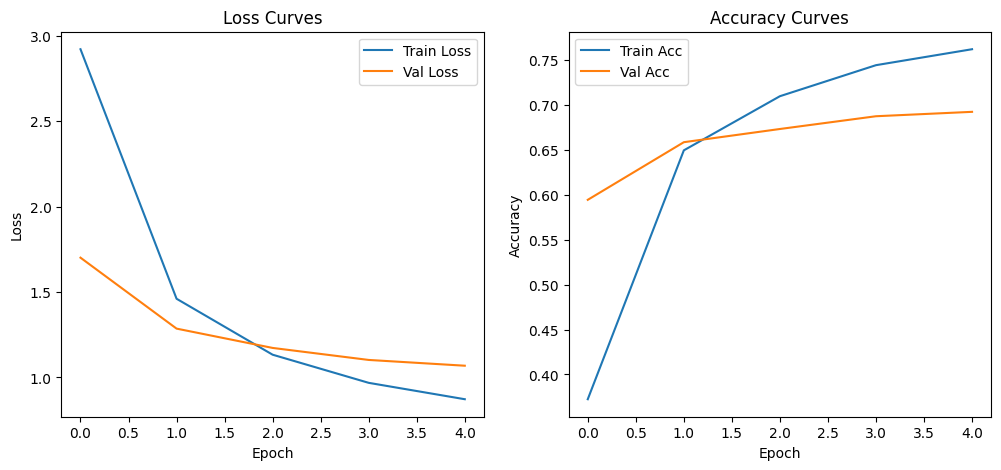

In [87]:
# Plot training and validation loss curves
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses, label="Train Loss")
ax[0].plot(val_losses, label="Val Loss")
ax[0].set_title("Loss Curves")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(train_accuracies, label="Train Acc")
ax[1].plot(val_accuracies, label="Val Acc")
ax[1].set_title("Accuracy Curves")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
plt.show()

In [89]:
# Save the trained model
torch.save(model.state_dict(), "../models/dog_classifier_resnet18.pth")